# A Geometric Notion of Singularity

*Course notes for **Math for Machine Learning**, C1 · W1 · L1 — "A geometric notion of singularity" (DeepLearning.AI).*

A system of two equations in two unknowns is a pair of **lines**. The geometry of how those lines sit relative to each other tells us everything about solutions and singularity:

| Geometry | Solutions | System | Matrix |
|----------|-----------|--------|--------|
| Lines cross at one point | unique | complete | **non-singular** |
| Lines coincide (same line) | infinitely many | redundant | **singular** |
| Lines parallel, distinct | none | contradictory | **singular** |

We use the lecture's variables: $a$ (apples) and $b$ (bananas).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_system(ax, rows, rhs, title, subtitle):
    """Plot two lines  r[0]*a + r[1]*b = c  on the (a, b) plane."""
    a = np.linspace(-2, 12, 200)
    colors = ["#1f77b4", "#d62728"]
    for (r, c, col) in zip(rows, rhs, colors):
        if r[1] != 0:                       # b = (c - r0*a) / r1
            ax.plot(a, (c - r[0] * a) / r[1], color=col, lw=2)
        else:                                # vertical line a = c / r0
            ax.axvline(c / r[0], color=col, lw=2)
    ax.axhline(0, color="0.7", lw=0.8); ax.axvline(0, color="0.7", lw=0.8)
    ax.set_xlim(-2, 12); ax.set_ylim(-2, 12)
    ax.set_xlabel("a"); ax.set_ylabel("b")
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.grid(alpha=0.25)

## 1. Three systems, three geometries

$$
\textbf{System 1}\;\begin{cases} a + b = 10 \\ a + 2b = 12 \end{cases}
\qquad
\textbf{System 2}\;\begin{cases} a + b = 10 \\ 2a + 2b = 20 \end{cases}
\qquad
\textbf{System 3}\;\begin{cases} a + b = 10 \\ 2a + 2b = 24 \end{cases}
$$

- **System 1** — two different lines that cross once → **unique solution** $(a,b)=(8,2)$. *Complete, non-singular.*
- **System 2** — the second equation is just the first $\times 2$; both draw the *same* line → **infinitely many solutions**. *Redundant, singular.*
- **System 3** — same slopes but inconsistent constants; the lines are *parallel and distinct* → **no solution**. *Contradictory, singular.*

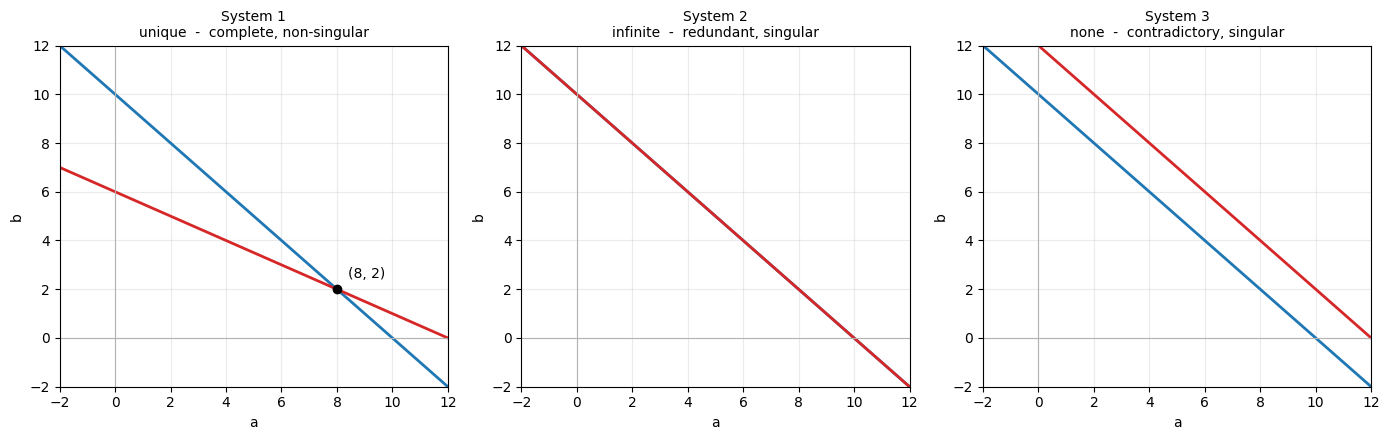

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

plot_system(axes[0], [[1, 1], [1, 2]], [10, 12],
            "System 1", "unique  -  complete, non-singular")
axes[0].scatter([8], [2], color="black", zorder=5)
axes[0].annotate("(8, 2)", (8, 2), textcoords="offset points", xytext=(8, 8))

plot_system(axes[1], [[1, 1], [2, 2]], [10, 20],
            "System 2", "infinite  -  redundant, singular")
plot_system(axes[2], [[1, 1], [2, 2]], [10, 24],
            "System 3", "none  -  contradictory, singular")

plt.tight_layout(); plt.show()

## 2. The geometric notion of singularity: set the constants to zero

Whether a system is singular should not depend on the constants on the right-hand side — only on the **coefficients** (the directions of the lines). To expose this, replace every constant with **0**:

$$
\textbf{System 1}\;\begin{cases} a + b = 0 \\ a + 2b = 0 \end{cases}
\qquad
\textbf{System 2}\;\begin{cases} a + b = 0 \\ 2a + 2b = 0 \end{cases}
\qquad
\textbf{System 3}\;\begin{cases} a + b = 0 \\ 2a + 2b = 0 \end{cases}
$$

Now every line passes through the **origin** $(0,0)$, so the trivial solution always works. The question becomes: is the origin the *only* solution?

- **System 1** — two distinct lines through the origin → they meet *only* there → **unique solution**. *Non-singular.*
- **System 2** and **System 3** — both equations reduce to the *same* line through the origin → **infinitely many solutions**. *Singular.*

Notice systems 2 and 3 are now **identical**. Zeroing the constants erased the difference between "redundant" and "contradictory": both were singular all along, and singularity is a property of the coefficients alone.

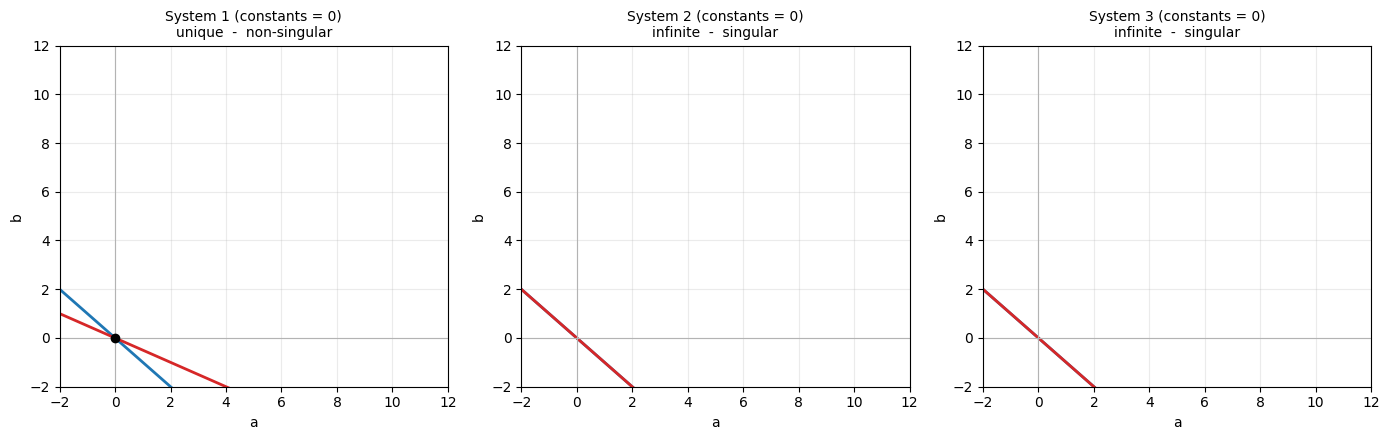

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

plot_system(axes[0], [[1, 1], [1, 2]], [0, 0],
            "System 1 (constants = 0)", "unique  -  non-singular")
axes[0].scatter([0], [0], color="black", zorder=5)

plot_system(axes[1], [[1, 1], [2, 2]], [0, 0],
            "System 2 (constants = 0)", "infinite  -  singular")
plot_system(axes[2], [[1, 1], [2, 2]], [0, 0],
            "System 3 (constants = 0)", "infinite  -  singular")

plt.tight_layout(); plt.show()

## 3. Confirming it with the determinant

Singularity lives entirely in the **coefficient matrix**. The determinant detects it:

$$ \det(A) \neq 0 \;\Rightarrow\; \text{non-singular (unique)} \qquad \det(A) = 0 \;\Rightarrow\; \text{singular} $$

The three systems share only two coefficient matrices — and the determinant tells them apart regardless of the right-hand side.

In [4]:
matrices = {
    "System 1": np.array([[1.0, 1.0], [1.0, 2.0]]),
    "System 2": np.array([[1.0, 1.0], [2.0, 2.0]]),
    "System 3": np.array([[1.0, 1.0], [2.0, 2.0]]),  # same coefficients as System 2
}
for name, A in matrices.items():
    det = np.linalg.det(A)
    label = "non-singular" if abs(det) > 1e-9 else "singular"
    print(f"{name}: det = {det:5.1f}  ->  {label}")

System 1: det =   1.0  ->  non-singular
System 2: det =   0.0  ->  singular
System 3: det =   0.0  ->  singular


## 4. Takeaways

- A 2×2 system is two **lines**; the solution set is their intersection.
- **Non-singular** = lines cross at a single point = unique solution.
- **Singular** = lines coincide (infinite solutions) *or* are parallel and distinct (no solution).
- **The geometric trick:** set all constants to 0. Every line then passes through the origin, and *singular systems collapse to the same line* while *non-singular systems still meet only at the origin*. This shows **singularity depends only on the coefficient matrix**, not the constants.
- The **determinant** of that coefficient matrix is the algebraic test: zero ⇒ singular, non-zero ⇒ non-singular.

*Related:* [Linear Algebra Applied 2](./C1_W1_L1_linear_algebra_applied_2.ipynb) introduced singular/non-singular via the determinant; here we see the geometry behind it.